# 1 Exercise-1
## 1.1 Data Exploration
### Q.1.1.1

Examine the summary statistics (mean, standard deviation, min, max, quartiles) of
all 81 features and the target. Which features show the highest variation? Justify
why comparing raw standard deviations across these features can be misleading,
and propose a more suitable measure.

In [43]:
from pathlib import Path
import pandas as pd
import zipfile
import urllib.request

def load_superconductivity_data():
    zip_path = Path("datasets/superconductivty+data.zip")
    if not zip_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://archive.ics.uci.edu/static/public/464/superconductivty+data.zip"
        urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(path="datasets/superconductivity")
    return pd.read_csv(Path("datasets/superconductivity/train.csv"))

data = load_superconductivity_data()

data.describe()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
count,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,...,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000
mean,4.115224,87.557631,72.988310,71.290627,58.539916,1.165608,1.063884,115.601251,33.225218,44.391893,...,3.153127,3.056536,3.055885,1.295682,1.052841,2.041010,1.483007,0.839342,0.673987,34.421219
std,1.439295,29.676497,33.490406,31.030272,36.651067,0.364930,0.401423,54.626887,26.967752,20.035430,...,1.191249,1.046257,1.174815,0.393155,0.380291,1.242345,0.978176,0.484676,0.455580,34.254362
min,1.000000,6.941000,6.423452,5.320573,1.960849,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000210
25%,3.000000,72.458076,52.143839,58.041225,35.248990,0.966676,0.775363,78.512902,16.824174,32.890369,...,2.116732,2.279705,2.091251,1.060857,0.775678,1.000000,0.921454,0.451754,0.306892,5.365000
50%,4.000000,84.922750,60.696571,66.361592,39.918385,1.199541,1.146783,122.906070,26.636008,45.123500,...,2.618182,2.615321,2.434057,1.368922,1.166532,2.000000,1.063077,0.800000,0.500000,20.000000
75%,5.000000,100.404410,86.103540,78.116681,73.113234,1.444537,1.359418,154.119320,38.356908,59.322812,...,4.026201,3.727919,3.914868,1.589027,1.330801,3.000000,1.918400,1.200000,1.020436,63.000000
max,9.000000,208.980400,208.980400,208.980400,208.980400,1.983797,1.958203,207.972460,205.589910,101.019700,...,7.000000,7.000000,7.000000,2.141963,1.949739,6.000000,6.992200,3.000000,3.000000,185.000000


In [44]:
features = data.drop(columns=['critical_temp'])
# if the 'material' formula column ended up in there too, drop that as well:
# features = data.drop(columns=['critical_temp', 'material'])

desc = features.describe().T

# Q: which features show the highest variation, by raw std?
top_std = desc.sort_values('std', ascending=False)
print(top_std[['mean', 'std']].head(10)) #I can add more, like min, max and etc., but to prove that raw std can be misleading, we will keep these two

bottom_std = desc.sort_values('std', ascending=True)
print(bottom_std[['mean', 'std']].head(10))


                          mean          std
range_Density      8665.438818  4097.126831
wtd_gmean_Density  3117.241110  3975.122587
gmean_Density      3460.692235  3703.256370
wtd_mean_Density   5267.188547  3221.314506
mean_Density       6111.465214  2846.785185
wtd_range_Density  2902.736814  2398.471020
std_Density        3416.910784  1673.624915
wtd_std_Density    3319.170628  1611.799629
range_fie           572.222612   309.614442
wtd_range_fie       483.517264   224.042874
                                     mean       std
wtd_entropy_ElectronAffinity     0.770757  0.285986
wtd_entropy_ThermalConductivity  0.539991  0.318248
wtd_entropy_Density              0.856037  0.319761
entropy_ThermalConductivity      0.727630  0.325976
wtd_entropy_fie                  0.926726  0.334018
entropy_Density                  1.072425  0.342356
entropy_ElectronAffinity         1.070250  0.343391
entropy_atomic_mass              1.165608  0.364930
wtd_entropy_FusionHeat           0.914065  0.370

Sorting the features by `std` (from `describe()`) shows that all `*_Density` features
have the highest raw standard deviation. This is because density is measured in kg/m³, so its values sit
on a much larger numeric scale. This makes comparing raw standard deviations across features misleading, since a feature's raw std reflects its unit/scale as much as its actual variability.

A more suitable measure is the **coefficient of variation** (CV) (`std / mean`). Accord to Science direct CV is a statistic that is the ratio of the standard deviation to the mean expressed in percentage (https://www.sciencedirect.com/topics/engineering/coefficient-of-variation).
  Which is scale-free and lets us compare relative spread regardless of units. Here is an example of the use of CV.

In [45]:
desc['CV_%'] = (desc['std'] / desc['mean']).abs() * 100   # coefficient of variation
top_cv = desc.sort_values('CV_%', ascending=False)
print(top_cv[['mean', 'std', 'CV_%']].head(10))

bottom_cv = desc.sort_values('CV_%', ascending=True)
print(top_cv[['mean', 'std', 'CV_%']].head(10))

                                      mean          std        CV_%
wtd_gmean_ThermalConductivity    27.308061    40.191150  147.176869
wtd_range_FusionHeat              8.218528    11.414066  138.882120
wtd_gmean_FusionHeat             10.141161    13.134007  129.511871
wtd_gmean_Density              3117.241110  3975.122587  127.520537
gmean_ThermalConductivity        29.841727    34.059581  114.134080
gmean_Density                  3460.692235  3703.256370  107.009122
std_FusionHeat                    8.323333     8.671651  104.184836
wtd_mean_FusionHeat              13.848001    14.279335  103.114779
gmean_FusionHeat                 10.136977    10.065901   99.298842
range_FusionHeat                 21.138994    20.370620   96.365133
                                      mean          std        CV_%
wtd_gmean_ThermalConductivity    27.308061    40.191150  147.176869
wtd_range_FusionHeat              8.218528    11.414066  138.882120
wtd_gmean_FusionHeat             10.141161    13

Ranking by CV instead of raw std gives a completely different result. `wtd_gmean_ThermalConductivity`,
`wtd_range_FusionHeat`, and `wtd_gmean_FusionHeat` now on the top and all density related features do not stand out. This confirms that
Density's high raw std was mostly a scale effect, not genuinely higher relative variability.

## Q.1.1.2

Plot the distribution of critical_temp before and after a log transform. Based on
the shape of the distributions, discuss whether the raw or the transformed target
should be used for regression later in this assignment.



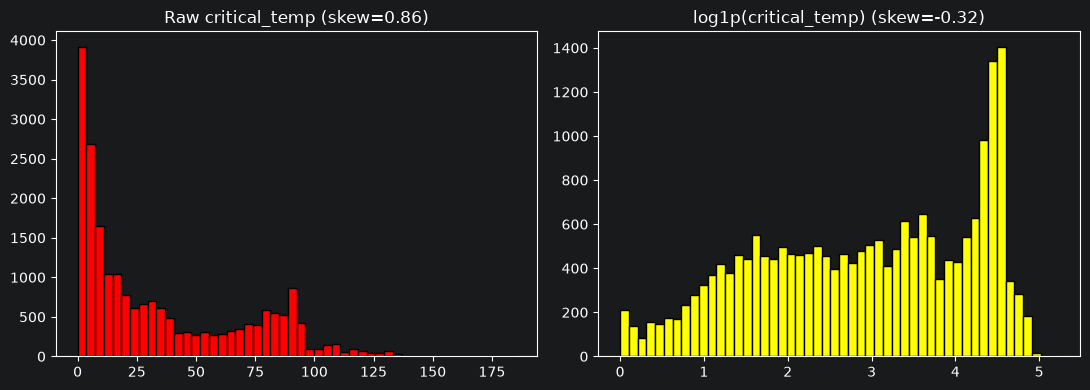

In [46]:
import numpy as np
import matplotlib.pyplot as plt

y = data['critical_temp'] # raw target, right-skewed
y_log = np.log1p(y)       # to reduce the risk of log(0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left plot: distribution of the raw target
axes[0].hist(y, bins=50, color='red', edgecolor='black')
axes[0].set_title(f'Raw critical_temp (skew={y.skew():.2f})')  # skew() quantifies how asymmetric the distribution is

# Right plot: distribution after log transform
axes[1].hist(y_log, bins=50, color='yellow', edgecolor='black')
axes[1].set_title(f'log1p(critical_temp) (skew={y_log.skew():.2f})')

plt.tight_layout()  # prevents titles/labels from overlapping between the two subplots
plt.show()

For regression, the **log-transformed target is preferable**. The raw `critical_temp` is right-skewed (skew ≈ 0.86): most materials have a low
critical temperature, but a few have unusually high values, creating a long tail.

(A right-skewed distribution has a long tail toward high values; a left-skewed one has
a long tail toward low values. A skew of 0 means the distribution is symmetric.)

Since regression models typically minimize squared error, these few high-value
outliers would have an outsized effect on the fit compared to the bulk of the data.
After `log1p`, the distribution becomes close to symmetric (skew ≈ -0.32), which is
a better match for standard regression assumptions.

One practical note: predictions made on the log scale must be back-transformed with
`np.expm1()` before computing error metrics (RMSE, MAE), so results stay interpretable
in Kelvin.

## 1.2 Correlation Analysis
### Q1.2.1
Compute the correlation matrix of all features. Since a full 81 × 81 heatmap
is unreadable, plot a heatmap restricted to the 15 features most correlated with
critical_temp

wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_mean_Valence               0.632401
wtd_entropy_atomic_mass        0.626930
wtd_gmean_Valence              0.615653
wtd_entropy_atomic_radius      0.603494
number_of_elements             0.601069
range_fie                      0.600790
mean_Valence                   0.600085
wtd_std_atomic_radius          0.599199
entropy_Valence                0.598591
wtd_entropy_Valence            0.589664
wtd_std_fie                    0.582013
Name: critical_temp, dtype: float64


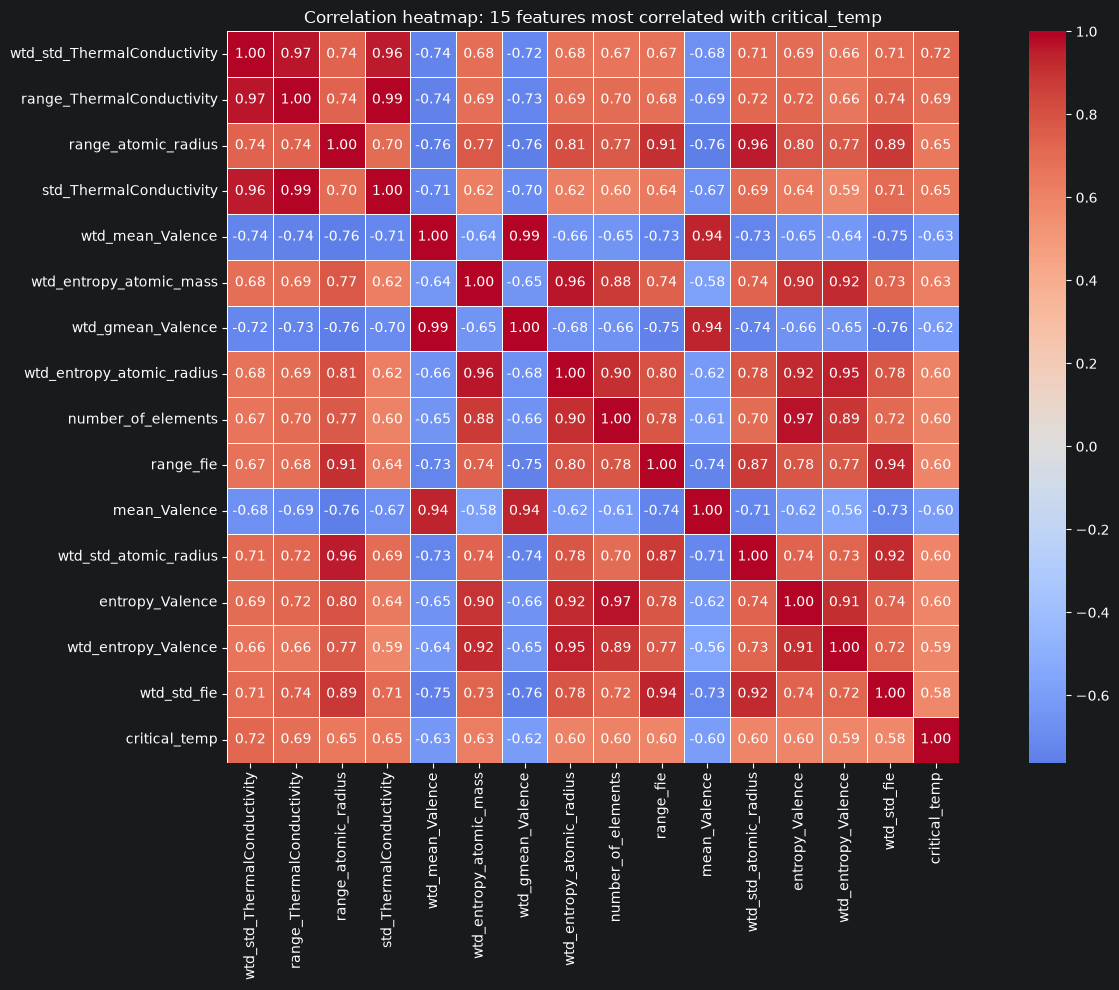

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

target = 'critical_temp'

# 1. Compute the full correlation matrix
correlation_matrix = data.corr(numeric_only=True)

# 2. Get correlations with the target only, dropping the target's self-correlation (always 1.0)
target_correlation = correlation_matrix[target].drop(target)

# 3. Rank by absolute correlation (so strong negative correlations count too) and take top 15
top15 = target_correlation.abs().sort_values(ascending=False).head(15)
print(top15)

# 4. Build a small correlation matrix restricted to those 15 features + the target
top15_features = top15.index
subset_corr = data[list(top15_features) + [target]].corr()

# 5. Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(subset_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation heatmap: 15 features most correlated with critical_temp')
plt.tight_layout()
plt.show()

The heatmap illustrates the correlation between the different features, and it ranges
from -1 to 1:

* +1 = perfect positive correlation (both go up together)
* -1 = perfect negative correlation (one goes up, the other goes down)
* 0 = no linear relationship

We chose to use a 15×15 subset because a full 81×81 correlation heatmap would contain
over 6,500 cells, which is unreadable. Restricting to the 15 features most correlated
with `critical_temp` keeps the heatmap readable while still highlighting the most
relevant relationships.

### Q1.2.2
Which variable has the strongest positive correlation with critical_temp? Which
variable has the strongest negative correlation?

In [48]:
sorted_corr = correlation_matrix[target].sort_values(ascending=False)

print(sorted_corr.head(2))   # top row is critical_temp itself (1.00), but we ignore it
print(sorted_corr.tail(2))   # most negative correlations are at the bottom

critical_temp                  1.000000
wtd_std_ThermalConductivity    0.721271
Name: critical_temp, dtype: float64
wtd_gmean_Valence   -0.615653
wtd_mean_Valence    -0.632401
Name: critical_temp, dtype: float64


The strongest positive correlation with `critical_temp` is `wtd_std_ThermalConductivity`
(r ≈ 0.72). The strongest negative correlation is `wtd_mean_Valence`
(r ≈ -0.63).

### Q1.2.3
Identify at least 5 pairs of features that are highly correlated with each other (ab-
solute correlation above 0.9), independent of their relationship with the target.
What problem does this create for a linear regression model, and how could it be
addressed?

In [49]:
import numpy as np

features = data.drop(columns=[target])  # exclude the target, we only want feature-vs-feature correlations
corr = features.corr(numeric_only=True)

# corr is a square, symmetric matrix: corr[A][B] == corr[B][A], and the diagonal
# is always 1.00 (every feature correlates perfectly with itself).
# We only want each pair counted once, so we keep just the values ABOVE the
# diagonal (the "upper triangle") and throw away everything else.
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)  # k=1 skips the diagonal too
pairs = corr.where(mask).stack()  # keep only the masked values, drop the rest (NaNs)

high_corr = pairs[pairs.abs() > 0.9].sort_values(ascending=False)
print(f'Number of pairs with |corr| > 0.9: {len(high_corr)}')
print(high_corr.head(10))

Number of pairs with |corr| > 0.9: 74
entropy_fie                entropy_atomic_radius      0.997739
wtd_mean_Valence           wtd_gmean_Valence          0.994939
entropy_fie                entropy_Valence            0.992726
wtd_mean_fie               wtd_gmean_fie              0.992331
mean_Valence               gmean_Valence              0.989911
entropy_atomic_radius      entropy_Valence            0.989546
range_ThermalConductivity  std_ThermalConductivity    0.987867
range_FusionHeat           std_FusionHeat             0.984574
range_fie                  std_fie                    0.981628
wtd_mean_atomic_radius     wtd_gmean_atomic_radius    0.980107
dtype: float64


When two features are highly correlated, they carry almost the same information.
Linear regression tries to assign each feature its own "weight" (coefficient) to show
how much it affects the target. But if two features move together, the model can't
tell which one is actually responsible for changes in critical_temp. It could give
credit to either one, or split it between them in a somewhat arbitrary way. This makes
the coefficients unstable: a tiny change in the data (or even just adding/removing a
few rows) can flip a coefficient from positive to negative, or make it swing wildly in
size, even though the model's overall predictions barely change. This makes the
coefficients unreliable to interpret (this is called **multicollinearity**).

### Q1.2.4
Using your correlation analysis, select one feature you expect to be a strong pre-
dictor of critical_temp and one you expect to be a weak predictor. Justify your
choice; you will use these two features in the next section.

In [50]:
corr = data.corr(numeric_only=True)[target].drop(target)
weakest = corr.abs().sort_values().head(5)
print(weakest)

gmean_fie                      0.025103
entropy_ThermalConductivity    0.085862
mean_fie                       0.102268
mean_atomic_radius             0.105273
wtd_gmean_ElectronAffinity     0.107359
Name: critical_temp, dtype: float64


As a strong predictor, we select **`wtd_std_ThermalConductivity`** (r ≈ 0.72 with
`critical_temp`), the highest correlation found in our analysis, suggesting a clear
linear relationship with the target.

As a weak predictor, we select **`gmean_fie`** (r ≈ 0.03), which shows almost no
linear relationship with `critical_temp`, making it a useful contrast case.

## 1.3 Linear Regression

### Q1.3.1
Fit a simple linear regression model using gradient descent to predict critical_temp
using only the weak predictor selected in Q1.2.4. Standardize the feature before
running gradient descent and explain why this matters here.

In [51]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

weak_feature = 'gmean_fie'   # from Q1.2.4

X = data[[weak_feature]].values
y = data[[target]].values

# split BEFORE scaling, so no information from the test set leaks into training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit the scaler on the training data only, then apply it to both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# add the bias column (x0 = 1) for the intercept term, same as the book does
X_train_b = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled]

eta = 0.1          # learning rate
n_epochs = 1000
m = len(X_train_b)

np.random.seed(42)
theta = np.random.randn(2, 1)   # [intercept, slope]

for epoch in range(n_epochs):
    gradients = 2 / m * X_train_b.T @ (X_train_b @ theta - y_train)
    theta = theta - eta * gradients

print("theta (intercept, slope):", theta.ravel())


theta (intercept, slope): [34.53330097 -0.86805412]


Without standardization, gradient descent diverges:

With a learning rate of 0.1, gradient descent didn't work on the raw feature. The
numbers blew up to nonsense within 50 steps. This happened because `gmean_fie` has
large raw values (roughly 375 to 1300), so each gradient descent step overshot by a
huge amount and kept getting worse instead of better. After standardizing the feature
(rescaling it to mean 0, standard deviation 1), the same learning rate worked fine and
the model converged normally.

Here is the code if we do not standardize the raw data:

In [54]:
# 1. Check the raw range of the feature
print(X_train.min(), X_train.max())

# 2. Run gradient descent on the UNSCALED feature (no StandardScaler), same settings
X_train_b_raw = np.c_[np.ones((len(X_train), 1)), X_train]

eta = 0.1
n_epochs = 1000
m = len(X_train_b_raw)

np.random.seed(42)
theta_raw = np.random.randn(2, 1)

for epoch in range(n_epochs):
    gradients = 2 / m * X_train_b_raw.T @ (X_train_b_raw @ theta_raw - y_train)
    theta_raw = theta_raw - eta * gradients

print("theta on RAW (unscaled) feature:", theta_raw.ravel())

375.5 1313.1
theta on RAW (unscaled) feature: [nan nan]


/tmp/ipykernel_12136/1535850189.py:15: RuntimeWarning: overflow encountered in matmul
  gradients = 2 / m * X_train_b_raw.T @ (X_train_b_raw @ theta_raw - y_train)
/tmp/ipykernel_12136/1535850189.py:16: RuntimeWarning: invalid value encountered in subtract
  theta_raw = theta_raw - eta * gradients
